# Data Exploration of Race and Ethnicity Disparities in Pregnancy

### Common Imports

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

In [2]:
raw_df = pd.read_parquet(
    open("../../../data/2024/processed/Nat2024_cleaned.parquet", "rb")
)

In [3]:
race_data_encoding_feature = "mothers_race_recode_6"

race_labels = [
    "White",
    "Black",
    "Native American",
    "Asian",
    "Native Hawaiian",
    "More than one race",
]

hispanic_data_encoding_feature = "mothers_hispanic_origin"

hispanic_labels = [
    "Not Hispanic",
    "Mexican",
    "Puerto Rican",
    "Cuban",
    "Central or South American",
    "Dominican",
    "Other Hispanic",
    "Unknown or Not Stated",
]

In [4]:
features_of_interest = [
    race_data_encoding_feature,
    hispanic_data_encoding_feature,
    "birth_place",
    "mothers_single_year_age",
    "marital_status",
    "mothers_education",
    "birth_weight_in_grams",
    "prior_births_now_living",
    "prior_other_terminations",
    "month_prenatal_care_started",
    "WIC",
    "cigarette_recode",
    "BMI",
    "pre_pregnancy_diabetes",
    "gestational_diabetes",
    "pre_pregnancy_hypertension",
    "gestational_hypertension",
    "hypertension_eclampsia",
    "previous_preterm_birth",
    "infertility_treatment_used",
    "previous_cesarean",
    "gonorrhea",
    "syphilis",
    "chlamydia",
    "hepatitis_b",
    "hepatitis_c",
    "induction_of_labor",
    "augmentation_of_labor",
    "steroids",
    "antibiotics",
    "chorioamnionitis",
    "anesthesia",
    "maternal_transfusion",
    "perineal_laceration",
    "ruptured_uterus",
    "unplanned_hysterectomy",
    "admit_to_intensive_care",
    "delivery_method_recode_7",
    "payment_recode",
    "combined_gestation_detail_in_weeks",
    "birth_weight_in_grams",
    "assisted_ventilation_immediate",
    "assisted_ventilation_after_6_hours",
    "admission_to_nicu",
    "surfactant",
    "antibiotics_for_newborn",
    "seizures",
    "infant_living_at_time_of_report",
]

In [5]:
df = raw_df[features_of_interest].copy()

### Feature Creation

In [10]:
df["is_hispanic"] = df[hispanic_data_encoding_feature].apply(
    lambda x: 0 if x in [0, 9] else 1
)

### Univariate Visualizations

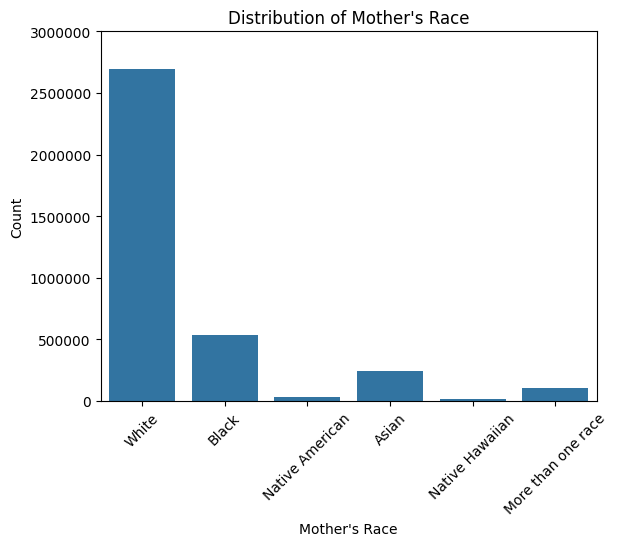

In [6]:
mothers_race_value_counts = df[race_data_encoding_feature].value_counts()

mothers_race_bar_ax = sns.barplot(
    x=mothers_race_value_counts.index, y=mothers_race_value_counts.values
)
mothers_race_bar_ax.set_xlabel("Mother's Race")
mothers_race_bar_ax.set_ylabel("Count")
mothers_race_bar_ax.set_xticks(range(len(race_labels)), race_labels, rotation=45)
mothers_race_bar_ax.set_yticks(
    ticks=range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
mothers_race_bar_ax.set_title("Distribution of Mother's Race")

plt.show()

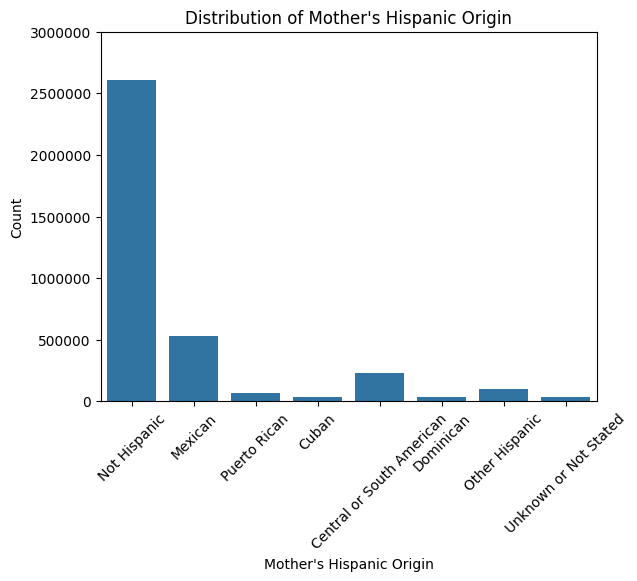

In [7]:
mothers_hispanic_origin_value_counts = df[hispanic_data_encoding_feature].value_counts()

mothers_hispanic_origin_bar_ax = sns.barplot(
    x=mothers_hispanic_origin_value_counts.index,
    y=mothers_hispanic_origin_value_counts.values,
)
mothers_hispanic_origin_bar_ax.set_xlabel("Mother's Hispanic Origin")
mothers_hispanic_origin_bar_ax.set_ylabel("Count")
mothers_hispanic_origin_bar_ax.set_xticks(
    range(len(hispanic_labels)), hispanic_labels, rotation=45
)
mothers_hispanic_origin_bar_ax.set_yticks(
    ticks=range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
mothers_hispanic_origin_bar_ax.set_title("Distribution of Mother's Hispanic Origin")

plt.show()

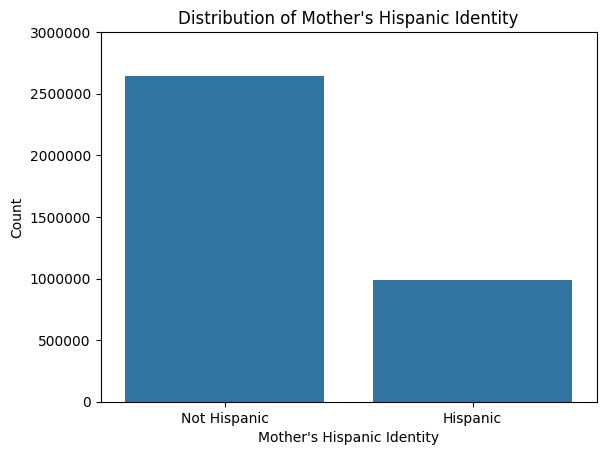

In [14]:
hispanic_value_counts = df["is_hispanic"].value_counts()

hispanic_bar_ax = sns.barplot(
    x=hispanic_value_counts.index, y=hispanic_value_counts.values
)
hispanic_bar_ax.set_xlabel("Mother's Hispanic Identity")
hispanic_bar_ax.set_ylabel("Count")
hispanic_bar_ax.set_xticks(range(2), ["Not Hispanic", "Hispanic"])
hispanic_bar_ax.set_yticks(
    ticks=range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
hispanic_bar_ax.set_title("Distribution of Mother's Hispanic Identity")

plt.show()

### Bivariate Visualizations By Race/Ethnicity

#### White

In [ ]:
birth_place_by_race_cross_tab = pd.crosstab(
    df["birth_place"], df.loc[df[race_data_encoding_feature] == 1]
)

birth_place_by_race_heatmap = sns.heatmap(
    birth_place_by_race_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
birth_place_by_race_heatmap.set_xlabel("Mother's Race")
birth_place_by_race_heatmap.set_ylabel("Birth Place")
birth_place_by_race_heatmap.set_xticklabels(race_labels, rotation=45)
birth_place_by_race_heatmap.set_yticklabels(
    [
        "Hospital",
        "Birth Center",
        "Home (Intended)",
        "Home (Not Intended)",
        "Home (Unknown Intention)",
        "Clinic",
        "Other",
        "Unknown",
    ],
    rotation=0,
)
birth_place_by_race_heatmap.set_title("Distribution of Birth Place by Mother's Race")
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (2698785, 49) instead